# Image Captioning 

## 1. Setup

In [1]:
import os
import json
import pickle
import random
import time
import types
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import transforms

import timm

import nltk
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

for pkg in ["punkt", "punkt_tab"]:
    try:
        nltk.data.find(f"tokenizers/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)

In [2]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

PROJECT_ROOT   = Path("..").resolve()
DATA_DIR       = PROJECT_ROOT / "data"
PROCESSED      = DATA_DIR / "processed"
IMAGE_DIR      = DATA_DIR / "images" / "val"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR    = PROJECT_ROOT / "results" / "weishu"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    print(f"device={device}  name={torch.cuda.get_device_name(0)}")
else:
    print(f"device={device}")

device=cuda  name=NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Load Phase 1 artefacts

In [3]:
class Vocabulary:
    """Word-level vocabulary with four special tokens (<pad>=0, <start>, <end>, <unk>)."""

    PAD, START, END, UNK = "<pad>", "<start>", "<end>", "<unk>"
    SPECIAL_TOKENS = [PAD, START, END, UNK]

    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        for tok in self.SPECIAL_TOKENS:
            self._add(tok)

    def _add(self, word):
        if word not in self.word2idx:
            i = len(self.word2idx)
            self.word2idx[word] = i
            self.idx2word[i] = word

    @classmethod
    def build(cls, tokenized_captions, min_freq=5):
        """Build a vocabulary from token-list iterables, keeping words with count >= min_freq."""
        counter = Counter()
        for tokens in tokenized_captions:
            counter.update(tokens)
        vocab = cls()
        for word, count in counter.items():
            if count >= min_freq:
                vocab._add(word)
        vocab.freq = counter
        return vocab

    @property
    def pad_idx(self):   return self.word2idx[self.PAD]
    @property
    def start_idx(self): return self.word2idx[self.START]
    @property
    def end_idx(self):   return self.word2idx[self.END]
    @property
    def unk_idx(self):   return self.word2idx[self.UNK]

    def encode(self, tokens, add_special=True):
        ids = [self.word2idx.get(t, self.unk_idx) for t in tokens]
        if add_special:
            ids = [self.start_idx] + ids + [self.end_idx]
        return ids

    def decode(self, ids, strip_special=True):
        words = []
        for i in ids:
            w = self.idx2word.get(int(i), self.UNK)
            if strip_special:
                if w == self.END: break
                if w in (self.PAD, self.START): continue
            words.append(w)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

In [4]:
with open(PROCESSED / "vocab.pkl", "rb") as f:
    vocab = pickle.load(f)
with open(PROCESSED / "train_data.pkl", "rb") as f:
    train_data = pickle.load(f)
with open(PROCESSED / "val_data.pkl", "rb") as f:
    val_data = pickle.load(f)
with open(PROCESSED / "test_data.pkl", "rb") as f:
    test_data = pickle.load(f)
with open(PROCESSED / "config.pkl", "rb") as f:
    config = pickle.load(f)

print(f"len(vocab)={len(vocab)}")
print(f"train/val/test={len(train_data)}/{len(val_data)}/{len(test_data)}")

len(vocab)=3214
train/val/test=5279/1131/1132


## 3. Hyperparameters

In [5]:
# === Shared ===
EMBED_DIM      = 256
DECODER_DIM    = 512
ENCODER_DIM    = 320              # EfficientNet-B0 stage-4 feature channels in timm features_only mode
DROPOUT        = 0.5
BATCH_SIZE     = 32
GRAD_CLIP      = 5.0
DECODER_LR     = 4e-4
ENCODER_LR     = 1e-5
ENCODER_UNFREEZE_EPOCH = 5
MAX_GEN_LEN    = 25

# === MODEL 1 ===
M1_MAX_EPOCHS           = 30
M1_EARLY_STOP_PATIENCE  = 5
M1_LR_REDUCE_PATIENCE   = 2
M1_BEAM_SIZE            = 3
M1_BEAM_ALPHA           = 0.7     # length penalty for beam search

# === MODEL 2 ===
M2_MAX_EPOCHS           = 60      # more epochs since Model 1 hadn't converged
M2_EARLY_STOP_PATIENCE  = 8
M2_LR_REDUCE_PATIENCE   = 3
M2_BEAM_SIZE            = 5       # larger beam
M2_BEAM_ALPHA           = 0.7
M2_LABEL_SMOOTHING      = 0.1
M2_SS_MAX_PROB          = 0.35    # scheduled sampling max probability
M2_SS_START_EPOCH       = 10      # no SS before this
M2_SS_FULL_EPOCH        = 45      # ramp to M2_SS_MAX_PROB by here

## 4. Dataset and DataLoader

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_train_transform():
    """ImageNet-normalised 224 random crop with horizontal flip."""
    return transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def get_eval_transform():
    """Deterministic 224 center crop for validation and test."""
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


class VizWizCaptionDataset(Dataset):
    """Image-caption dataset; train yields one (image, caption_ids) pair, eval yields (image, list[ref_ids])."""

    def __init__(self, data, vocab, transform, mode="train"):
        assert mode in ("train", "eval")
        self.data = data
        self.vocab = vocab
        self.transform = transform
        self.mode = mode

        if mode == "train":
            self.samples = [
                (item["image_path"], cap)
                for item in data for cap in item["captions_tokens"]
            ]
        else:
            self.samples = [
                (item["image_path"], item["captions_tokens"])
                for item in data
            ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, caps = self.samples[idx]
        image = self.transform(Image.open(path).convert("RGB"))
        if self.mode == "train":
            return image, torch.tensor(self.vocab.encode(caps), dtype=torch.long)
        refs = [self.vocab.encode(c, add_special=False) for c in caps]
        return image, refs


def collate_train(batch, pad_idx=0):
    """Stack images, pad caption tensors to the longest sequence in the batch."""
    images, captions = zip(*batch)
    images = torch.stack(images, dim=0)
    lengths = torch.tensor([len(c) for c in captions], dtype=torch.long)
    padded = pad_sequence(captions, batch_first=True, padding_value=pad_idx)
    return images, padded, lengths


def collate_eval(batch):
    """Stack images; references stay as nested Python lists (variable length per image)."""
    images, refs = zip(*batch)
    return torch.stack(images, dim=0), list(refs)

In [7]:
train_ds = VizWizCaptionDataset(train_data, vocab, get_train_transform(), mode="train")
val_ds   = VizWizCaptionDataset(val_data,   vocab, get_eval_transform(),  mode="eval")
test_ds  = VizWizCaptionDataset(test_data,  vocab, get_eval_transform(),  mode="eval")

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    collate_fn=lambda b: collate_train(b, pad_idx=vocab.pad_idx),
)
val_loader  = DataLoader(val_ds,  batch_size=16, shuffle=False, num_workers=0, collate_fn=collate_eval)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0, collate_fn=collate_eval)

images, captions, lengths = next(iter(train_loader))
print("train:", images.shape, captions.shape, lengths[:5].tolist())

images, refs = next(iter(val_loader))
print("val  :", images.shape, "refs[0] count:", len(refs[0]))

images, refs = next(iter(test_loader))
print("test :", images.shape, "refs[0] count:", len(refs[0]))

train: torch.Size([32, 3, 224, 224]) torch.Size([32, 27]) [13, 13, 12, 10, 12]
val  : torch.Size([16, 3, 224, 224]) refs[0] count: 5
test : torch.Size([16, 3, 224, 224]) refs[0] count: 4


## 5. Model Architecture

### 5.1 EfficientNetEncoder

In [8]:
class EfficientNetEncoder(nn.Module):
    """Frozen EfficientNet-B0 backbone exposing the stage-4 feature map (320 channels, 7x7 spatial)."""

    def __init__(self):
        super().__init__()
        self.model = timm.create_model(
            "efficientnet_b0", pretrained=True, features_only=True, out_indices=(4,),
        )
        self.fine_tune(False)

    def forward(self, images):
        feat = self.model(images)[0]              # (B, 320, 7, 7)
        # Flatten spatial dims so the decoder can attend over 49 positions.
        feat = feat.permute(0, 2, 3, 1).contiguous()
        B, H, W, C = feat.shape
        return feat.view(B, H * W, C)             # (B, 49, 320)

    def fine_tune(self, flag):
        """Freeze everything, optionally unfreeze the deepest two conv stages."""
        for p in self.model.parameters():
            p.requires_grad = False
        if flag:
            # We freeze the whole encoder initially and only unfreeze the deepest stages later, after the
            # decoder has warmed up — full fine-tuning early on dominates the decoder gradient and
            # destabilises training.
            for p in self.model.blocks[5:].parameters():
                p.requires_grad = True

### 5.2 LuongAttention

In [9]:
class LuongAttention(nn.Module):
    """Luong's 'general' attention: score(h_t, h_s) = h_t^T W h_s."""

    def __init__(self, encoder_dim, decoder_dim):
        super().__init__()
        self.W = nn.Linear(encoder_dim, decoder_dim, bias=False)

    def forward(self, encoder_out, decoder_hidden):
        # encoder_out: (B, S, enc_dim); decoder_hidden: (B, dec_dim)
        encoder_proj = self.W(encoder_out)                                       # (B, S, dec_dim)
        scores = (encoder_proj @ decoder_hidden.unsqueeze(2)).squeeze(2)         # (B, S)
        alpha = F.softmax(scores, dim=1)
        context = (alpha.unsqueeze(1) @ encoder_out).squeeze(1)                  # (B, enc_dim)
        return context, alpha

### 5.3 CaptionDecoder

In [10]:
class CaptionDecoder(nn.Module):
    """GRU decoder with Luong attention; supports teacher forcing, scheduled sampling, greedy, and beam decoding."""

    def __init__(self, vocab_size, embed_dim, encoder_dim, decoder_dim, pad_idx, dropout=0.5):
        super().__init__()
        self.vocab_size = vocab_size
        self.encoder_dim = encoder_dim
        self.decoder_dim = decoder_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRUCell(embed_dim + encoder_dim, decoder_dim)
        self.attention = LuongAttention(encoder_dim, decoder_dim)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.W_c = nn.Linear(encoder_dim + decoder_dim, decoder_dim)
        self.fc_out = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def init_hidden(self, encoder_out):
        """Initialise decoder hidden state from the mean-pooled encoder features."""
        return torch.tanh(self.init_h(encoder_out.mean(dim=1)))

    def step(self, word_emb, h, encoder_out):
        """One decoder step: returns (logits, new_hidden, attention_weights)."""
        context, alpha = self.attention(encoder_out, h)
        gru_in = torch.cat([word_emb, context], dim=1)
        h = self.gru(gru_in, h)
        attn_h = torch.tanh(self.W_c(torch.cat([context, h], dim=1)))
        logits = self.fc_out(self.dropout(attn_h))
        return logits, h, alpha

    def forward(self, encoder_out, captions, lengths):
        """Teacher-forced decoding; returns (logits (B, T-1, V), alphas (B, T-1, S))."""
        B, T = captions.size()
        S = encoder_out.size(1)
        h = self.init_hidden(encoder_out)
        predictions = encoder_out.new_zeros(B, T - 1, self.vocab_size)
        alphas = encoder_out.new_zeros(B, T - 1, S)
        for t in range(T - 1):
            word_emb = self.embedding(captions[:, t])
            logits, h, alpha = self.step(word_emb, h, encoder_out)
            predictions[:, t] = logits
            alphas[:, t] = alpha
        return predictions, alphas

    def forward_ss(self, encoder_out, captions, lengths, ss_prob):
        """Teacher forcing with scheduled sampling at probability ss_prob."""
        if ss_prob == 0:
            return self.forward(encoder_out, captions, lengths)
        B, T = captions.size()
        S = encoder_out.size(1)
        device = encoder_out.device
        h = self.init_hidden(encoder_out)
        predictions = encoder_out.new_zeros(B, T - 1, self.vocab_size)
        alphas = encoder_out.new_zeros(B, T - 1, S)
        prev_pred = None
        for t in range(T - 1):
            # The first step always uses the ground-truth <start> token; sampling kicks in from t > 0.
            if t == 0 or prev_pred is None:
                inp = captions[:, t]
            else:
                sample_mask = (torch.rand(B, device=device) < ss_prob)
                inp = torch.where(sample_mask, prev_pred, captions[:, t])
            word_emb = self.embedding(inp)
            logits, h, alpha = self.step(word_emb, h, encoder_out)
            predictions[:, t] = logits
            alphas[:, t] = alpha
            prev_pred = logits.argmax(-1).detach()
        return predictions, alphas

    def generate_greedy(self, encoder_out, start_idx, end_idx, max_len):
        """Greedy decoding; returns (seqs (B, T), alphas (B, T, S)). Stops early once every image emits <end>."""
        B = encoder_out.size(0)
        S = encoder_out.size(1)
        device = encoder_out.device
        h = self.init_hidden(encoder_out)
        cur = torch.full((B,), start_idx, dtype=torch.long, device=device)
        seqs = []
        alphas = []
        done = torch.zeros(B, dtype=torch.bool, device=device)
        for _ in range(max_len):
            word_emb = self.embedding(cur)
            logits, h, alpha = self.step(word_emb, h, encoder_out)
            cur = logits.argmax(-1)
            seqs.append(cur)
            alphas.append(alpha)
            done = done | (cur == end_idx)
            if done.all():
                break
        return torch.stack(seqs, dim=1), torch.stack(alphas, dim=1)

    def generate_beam(self, encoder_out, start_idx, end_idx, max_len, beam_size, alpha=0.7):
        """Single-image beam search with length-normalised scoring; encoder_out must be (1, S, C)."""
        assert encoder_out.size(0) == 1, "generate_beam expects a single image; loop over batch externally."
        device = encoder_out.device
        K = beam_size

        # Replicate the (frozen) encoder features across all beams; the hidden state starts from beam 0 only
        # so we don't kick off with K identical paths.
        enc = encoder_out.expand(K, -1, -1).contiguous()
        h = self.init_hidden(encoder_out).expand(K, -1).contiguous()

        seqs = torch.full((K, 1), start_idx, dtype=torch.long, device=device)
        scores = torch.full((K,), -1e9, device=device)
        scores[0] = 0.0

        finished = []  # list of (length-normalised score, sequence as Python list)

        for _ in range(max_len):
            word_emb = self.embedding(seqs[:, -1])
            logits, h_new, _ = self.step(word_emb, h, enc)
            log_probs = F.log_softmax(logits, dim=-1)            # (K, V)

            combined = scores.unsqueeze(1) + log_probs           # (K, V) cumulative log-probs
            flat = combined.view(-1)
            top_scores, top_idx = flat.topk(K)
            beam_id = top_idx // self.vocab_size
            word_id = top_idx % self.vocab_size

            seqs = torch.cat([seqs[beam_id], word_id.unsqueeze(1)], dim=1)
            h = h_new[beam_id]
            scores = top_scores

            for b in range(K):
                if word_id[b].item() == end_idx:
                    seq = seqs[b].tolist()
                    # Length penalty α prevents the model from preferring overly short captions;
                    # α=0.7 is the Google NMT default. length here is the full sequence including <start>/<end>.
                    norm = scores[b].item() / (len(seq) ** alpha)
                    finished.append((norm, seq))
                    scores[b] = -1e9

            if scores.max().item() <= -1e8:
                break

        # No beams finished within max_len -> score whatever's left with the same formula.
        for b in range(K):
            if scores[b].item() > -1e8:
                seq = seqs[b].tolist()
                norm = scores[b].item() / (len(seq) ** alpha)
                finished.append((norm, seq))

        finished.sort(key=lambda x: x[0], reverse=True)
        return finished[0][1]

### 5.4 CaptioningModel

In [11]:
class CaptioningModel(nn.Module):
    """Thin wrapper bundling the encoder and decoder."""

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, images, captions, lengths):
        return self.decoder(self.encoder(images), captions, lengths)

    def forward_ss(self, images, captions, lengths, ss_prob):
        return self.decoder.forward_ss(self.encoder(images), captions, lengths, ss_prob)

    @torch.no_grad()
    def caption_greedy(self, images, start, end, max_len):
        enc = self.encoder(images)
        return self.decoder.generate_greedy(enc, start, end, max_len)

    @torch.no_grad()
    def caption_beam(self, images, start, end, max_len, beam_size, alpha):
        enc = self.encoder(images)
        return [
            self.decoder.generate_beam(enc[i:i + 1], start, end, max_len, beam_size, alpha)
            for i in range(enc.size(0))
        ]

### 5.5 Encoder shape sanity check

In [12]:
_enc = EfficientNetEncoder().to(device).eval()
with torch.no_grad():
    _out = _enc(torch.randn(2, 3, 224, 224, device=device))
print("encoder out:", _out.shape)
assert _out.shape == (2, 49, ENCODER_DIM), f"unexpected encoder out: {_out.shape}"
del _enc

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


encoder out: torch.Size([2, 49, 320])


## 6. Loss, BLEU evaluation, training utilities

### 6.1 Cross-entropy loss for Model 1

In [13]:
# ignore_index skips padding positions so they don't contribute to the loss.
criterion_m1 = nn.CrossEntropyLoss(ignore_index=vocab.pad_idx)

### 6.2 Label-smoothed loss for Model 2

In [14]:
def label_smoothed_nll(logits, targets, eps, pad_idx):
    """KL-divergence-style label smoothing, ignoring pad positions."""
    # logits: (N, V); targets: (N,)
    # Soft target distribution: (1 - eps) on the true class + eps/V uniform mass over all classes.
    N, V = logits.size()
    log_probs = F.log_softmax(logits, dim=-1)
    soft = torch.full_like(log_probs, eps / V)
    soft.scatter_(1, targets.unsqueeze(1), (1.0 - eps) + eps / V)
    mask = (targets != pad_idx).float()
    per_token = -(soft * log_probs).sum(dim=-1)
    return (per_token * mask).sum() / mask.sum().clamp(min=1)


# Sanity: with eps=0 the smoothed loss should match plain CE (ignore_index=pad)
_logits = torch.randn(20, len(vocab))
_targets = torch.randint(0, len(vocab), (20,))
_targets[0] = vocab.pad_idx                 # include a pad to test masking
_a = label_smoothed_nll(_logits, _targets, eps=0.0, pad_idx=vocab.pad_idx)
_b = F.cross_entropy(_logits, _targets, ignore_index=vocab.pad_idx)
print(f"smoothed (eps=0) vs CE: {_a.item():.6f} vs {_b.item():.6f}")
assert torch.allclose(_a, _b, atol=1e-5)

smoothed (eps=0) vs CE: 8.414351 vs 8.414352


### 6.3 BLEU evaluation

In [15]:
def ids_to_words(ids, vocab):
    """Decode an id sequence to a list of word strings; stop at <end>, skip <pad>/<start>."""
    words = []
    for i in ids:
        w = vocab.idx2word.get(int(i), vocab.UNK)
        if w == vocab.END:
            break
        if w in (vocab.PAD, vocab.START):
            continue
        words.append(w)
    return words


def compute_bleu(predictions, references, vocab):
    """Corpus-level BLEU-1..4 using NLTK smoothing method 1."""
    hyps = [ids_to_words(p, vocab) for p in predictions]
    refs = [[ids_to_words(r, vocab) for r in ref_set] for ref_set in references]
    smooth = SmoothingFunction().method1
    return {
        "BLEU-1": corpus_bleu(refs, hyps, weights=(1.0, 0, 0, 0), smoothing_function=smooth),
        "BLEU-2": corpus_bleu(refs, hyps, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth),
        "BLEU-3": corpus_bleu(refs, hyps, weights=(1/3, 1/3, 1/3, 0), smoothing_function=smooth),
        "BLEU-4": corpus_bleu(refs, hyps, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth),
    }


def evaluate(model, loader, vocab, decode="greedy", beam_size=3, beam_alpha=0.7, max_len=25):
    """Generate captions for every image in loader and return (bleu_dict, predictions, references)."""
    model.eval()
    predictions = []
    references = []
    with torch.no_grad():
        for images, refs_batch in loader:
            images = images.to(device)
            if decode == "greedy":
                seqs, _ = model.caption_greedy(images, vocab.start_idx, vocab.end_idx, max_len)
                seqs = seqs.cpu().tolist()
            elif decode == "beam":
                seqs = model.caption_beam(images, vocab.start_idx, vocab.end_idx, max_len, beam_size, beam_alpha)
            else:
                raise ValueError(f"unknown decode mode: {decode}")
            predictions.extend(seqs)
            references.extend(refs_batch)
    return compute_bleu(predictions, references, vocab), predictions, references

### 6.4 Scheduled sampling schedule

In [16]:
def get_ss_prob(epoch, start, full, max_prob):
    """Linear ramp from 0 (before `start`) to `max_prob` (at `full`)."""
    if epoch < start:
        return 0.0
    if epoch >= full:
        return max_prob
    return max_prob * (epoch - start) / (full - start)


print([(e, round(get_ss_prob(e, M2_SS_START_EPOCH, M2_SS_FULL_EPOCH, M2_SS_MAX_PROB), 4))
       for e in [0, 5, 10, 25, 45, 60]])

[(0, 0.0), (5, 0.0), (10, 0.0), (25, 0.15), (45, 0.35), (60, 0.35)]


## 7. Model 1 — Training

### 7.1 Build Model 1

In [17]:
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

encoder_m1 = EfficientNetEncoder()
decoder_m1 = CaptionDecoder(
    vocab_size=len(vocab), embed_dim=EMBED_DIM, encoder_dim=ENCODER_DIM,
    decoder_dim=DECODER_DIM, pad_idx=vocab.pad_idx, dropout=DROPOUT,
)
model_m1 = CaptioningModel(encoder_m1, decoder_m1).to(device)

optimizer_m1 = torch.optim.Adam([
    {"params": model_m1.encoder.parameters(), "lr": ENCODER_LR},
    {"params": model_m1.decoder.parameters(), "lr": DECODER_LR},
])
scheduler_m1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_m1, mode="max", patience=M1_LR_REDUCE_PATIENCE, factor=0.5,
)

total_params = sum(p.numel() for p in model_m1.parameters())
trainable_params = sum(p.numel() for p in model_m1.parameters() if p.requires_grad)
print(f"Model 1 — total params: {total_params:,}  trainable: {trainable_params:,}")

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Model 1 — total params: 8,495,882  trainable: 4,900,494


### 7.2 Training loop

In [18]:
history_m1 = {"train_loss": [], "val_bleu": []}
best_bleu_m1 = -1.0
best_epoch_m1 = -1
patience_left = M1_EARLY_STOP_PATIENCE
V = len(vocab)

for epoch in range(M1_MAX_EPOCHS):
    t0 = time.time()

    if epoch == ENCODER_UNFREEZE_EPOCH:
        model_m1.encoder.fine_tune(True)
        print(f"Encoder unfrozen at epoch {epoch}")

    model_m1.train()
    losses = []
    for images, captions, lengths in tqdm(train_loader, desc=f"M1 ep{epoch} train", leave=False):
        images = images.to(device)
        captions = captions.to(device)
        predictions, _ = model_m1(images, captions, lengths)
        targets = captions[:, 1:]
        loss = criterion_m1(predictions.reshape(-1, V), targets.reshape(-1))

        optimizer_m1.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_m1.parameters(), GRAD_CLIP)
        optimizer_m1.step()

        losses.append(loss.item())
    train_loss = float(np.mean(losses))

    bleu, _, _ = evaluate(model_m1, val_loader, vocab, decode="greedy", max_len=MAX_GEN_LEN)
    scheduler_m1.step(bleu["BLEU-4"])

    enc_lr = optimizer_m1.param_groups[0]["lr"]
    dec_lr = optimizer_m1.param_groups[1]["lr"]
    dt = time.time() - t0

    print(
        f"Epoch {epoch} | train_loss={train_loss:.3f} | "
        f"val BLEU-1/2/3/4="
        f"{bleu['BLEU-1']:.3f}/{bleu['BLEU-2']:.3f}/{bleu['BLEU-3']:.3f}/{bleu['BLEU-4']:.3f} | "
        f"lr(enc/dec)={enc_lr:.1e}/{dec_lr:.1e} | time={dt:.0f}s"
    )

    history_m1["train_loss"].append(train_loss)
    history_m1["val_bleu"].append(bleu)

    if bleu["BLEU-4"] > best_bleu_m1:
        best_bleu_m1 = bleu["BLEU-4"]
        best_epoch_m1 = epoch
        patience_left = M1_EARLY_STOP_PATIENCE
        torch.save({
            "epoch": epoch,
            "model_state": model_m1.state_dict(),
            "optimizer_state": optimizer_m1.state_dict(),
            "val_bleu": bleu,
        }, CHECKPOINT_DIR / "weishu_model1_best.pt")
    else:
        patience_left -= 1
        if patience_left <= 0:
            print(f"Early stopping at epoch {epoch} (no BLEU-4 improvement for {M1_EARLY_STOP_PATIENCE} epochs)")
            break

print(f"\nModel 1 best val BLEU-4={best_bleu_m1:.4f} at epoch {best_epoch_m1}")

M1 ep0 train:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch 0 | train_loss=5.702 | val BLEU-1/2/3/4=0.299/0.169/0.081/0.027 | lr(enc/dec)=1.0e-05/4.0e-04 | time=378s


M1 ep1 train:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch 1 | train_loss=4.732 | val BLEU-1/2/3/4=0.317/0.188/0.100/0.052 | lr(enc/dec)=1.0e-05/4.0e-04 | time=363s


M1 ep2 train:   0%|          | 0/725 [00:00<?, ?it/s]

...

Epoch 27 | train_loss=2.424 | val BLEU-1/2/3/4=0.562/0.360/0.224/0.139 | lr(enc/dec)=5.0e-06/2.0e-04 | time=358s


M1 ep28 train:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch 28 | train_loss=2.391 | val BLEU-1/2/3/4=0.534/0.341/0.211/0.130 | lr(enc/dec)=5.0e-06/2.0e-04 | time=366s


M1 ep29 train:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch 29 | train_loss=2.365 | val BLEU-1/2/3/4=0.556/0.358/0.222/0.137 | lr(enc/dec)=2.5e-06/1.0e-04 | time=371s

Model 1 best val BLEU-4=0.1439 at epoch 26


### 7.3 Training curves

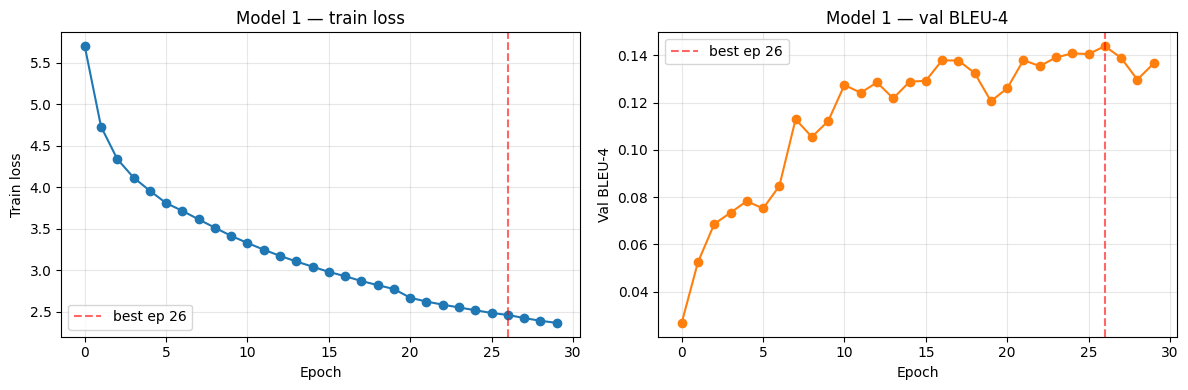

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_m1["train_loss"], marker="o", color="C0")
axes[0].axvline(best_epoch_m1, color="red", linestyle="--", alpha=0.6, label=f"best ep {best_epoch_m1}")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss"); axes[0].set_title("Model 1 — train loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

bleu4 = [b["BLEU-4"] for b in history_m1["val_bleu"]]
axes[1].plot(bleu4, marker="o", color="C1")
axes[1].axvline(best_epoch_m1, color="red", linestyle="--", alpha=0.6, label=f"best ep {best_epoch_m1}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val BLEU-4"); axes[1].set_title("Model 1 — val BLEU-4")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7.4 Test evaluation

In [20]:
ckpt = torch.load(CHECKPOINT_DIR / "weishu_model1_best.pt", map_location=device)
model_m1.load_state_dict(ckpt["model_state"])

m1_test_greedy, m1_pred_greedy, m1_refs = evaluate(
    model_m1, test_loader, vocab, decode="greedy", max_len=MAX_GEN_LEN,
)
m1_test_beam, m1_pred_beam, _ = evaluate(
    model_m1, test_loader, vocab, decode="beam",
    beam_size=M1_BEAM_SIZE, beam_alpha=M1_BEAM_ALPHA, max_len=MAX_GEN_LEN,
)
print("Model 1 test (greedy):", {k: round(v, 4) for k, v in m1_test_greedy.items()})
print(f"Model 1 test (beam={M1_BEAM_SIZE}, α={M1_BEAM_ALPHA}):",
      {k: round(v, 4) for k, v in m1_test_beam.items()})

Model 1 test (greedy): {'BLEU-1': 0.5729, 'BLEU-2': 0.3658, 'BLEU-3': 0.2257, 'BLEU-4': 0.1352}
Model 1 test (beam=3, α=0.7): {'BLEU-1': 0.5881, 'BLEU-2': 0.3858, 'BLEU-3': 0.2504, 'BLEU-4': 0.1586}


### 7.5 Qualitative samples — Model 1

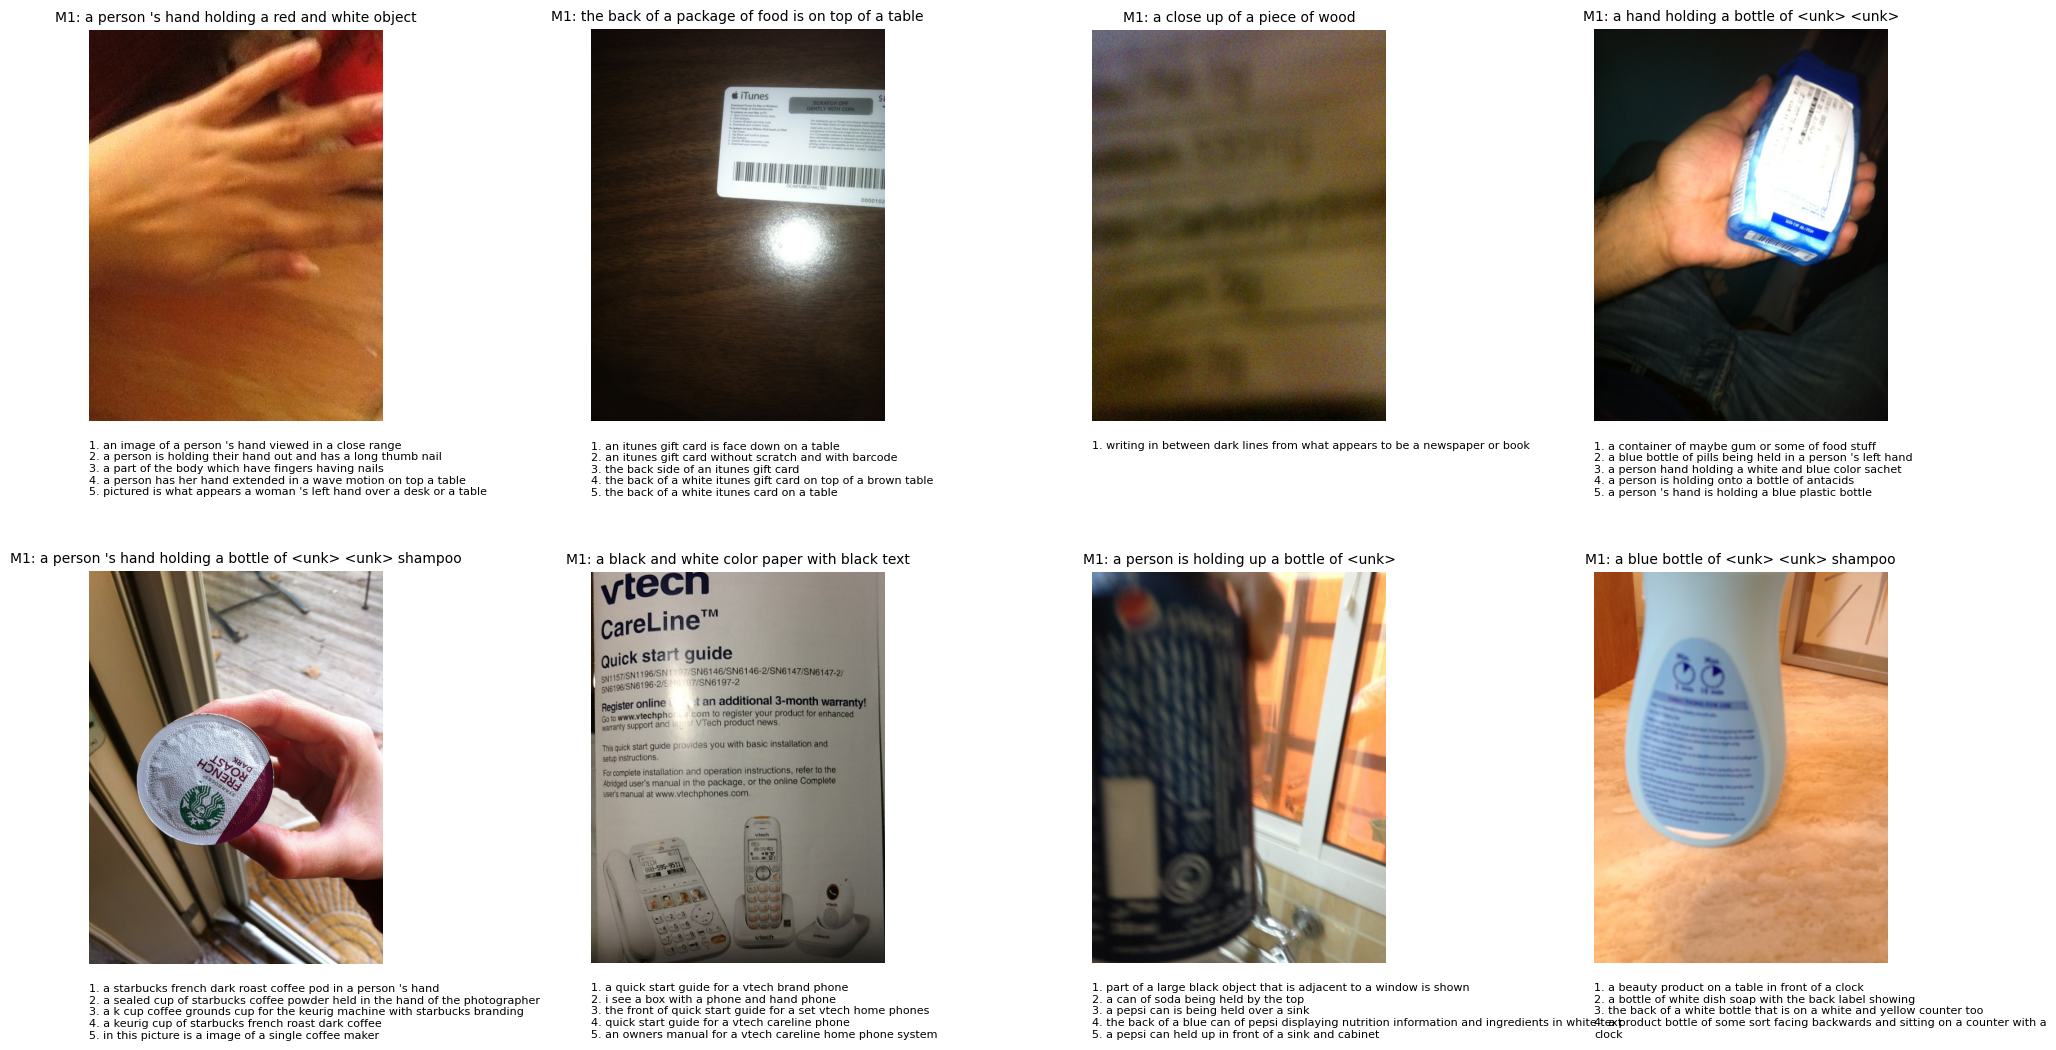

In [21]:
rng = random.Random(RANDOM_SEED)
sample_indices = rng.sample(range(len(test_data)), 8)


def caption_one(model, item, beam_size, beam_alpha):
    """Return the beam-decoded caption (string) for one test record."""
    img = get_eval_transform()(Image.open(item["image_path"]).convert("RGB")).unsqueeze(0).to(device)
    seq = model.caption_beam(img, vocab.start_idx, vocab.end_idx, MAX_GEN_LEN, beam_size, beam_alpha)[0]
    return " ".join(ids_to_words(seq, vocab))


fig, axes = plt.subplots(2, 4, figsize=(20, 11))
for ax, idx in zip(axes.flat, sample_indices):
    item = test_data[idx]
    ax.imshow(Image.open(item["image_path"]).convert("RGB"))
    ax.axis("off")
    pred = caption_one(model_m1, item, M1_BEAM_SIZE, M1_BEAM_ALPHA)
    refs = "\n".join(f"{i+1}. {' '.join(t)}" for i, t in enumerate(item["captions_tokens"]))
    ax.set_title(f"M1: {pred}", fontsize=10)
    ax.text(0, -0.05, refs, transform=ax.transAxes, fontsize=8, va="top", wrap=True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "model1_samples.png", dpi=130, bbox_inches="tight")
plt.show()

### 7.6 Save Model 1 artefacts

In [22]:
with open(RESULTS_DIR / "model1_metrics.json", "w", encoding="utf-8") as f:
    json.dump({
        "greedy": m1_test_greedy,
        "beam": m1_test_beam,
        "beam_size": M1_BEAM_SIZE,
        "beam_alpha": M1_BEAM_ALPHA,
    }, f, indent=2)

with open(RESULTS_DIR / "model1_history.json", "w", encoding="utf-8") as f:
    json.dump({
        "train_loss": history_m1["train_loss"],
        "val_bleu": history_m1["val_bleu"],
    }, f, indent=2)

print("saved model1_metrics.json and model1_history.json")

saved model1_metrics.json and model1_history.json


## 8. Model 2 — Improved training strategy

### 8.1 Build Model 2

In [23]:
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

encoder_m2 = EfficientNetEncoder()
decoder_m2 = CaptionDecoder(
    vocab_size=len(vocab), embed_dim=EMBED_DIM, encoder_dim=ENCODER_DIM,
    decoder_dim=DECODER_DIM, pad_idx=vocab.pad_idx, dropout=DROPOUT,
)
model_m2 = CaptioningModel(encoder_m2, decoder_m2).to(device)

optimizer_m2 = torch.optim.Adam([
    {"params": model_m2.encoder.parameters(), "lr": ENCODER_LR},
    {"params": model_m2.decoder.parameters(), "lr": DECODER_LR},
])
scheduler_m2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_m2, mode="max", patience=M2_LR_REDUCE_PATIENCE, factor=0.5,
)

total_params = sum(p.numel() for p in model_m2.parameters())
trainable_params = sum(p.numel() for p in model_m2.parameters() if p.requires_grad)
print(f"Model 2 — total params: {total_params:,}  trainable: {trainable_params:,}")

Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Model 2 — total params: 8,495,882  trainable: 4,900,494


### 8.2 Training loop

In [24]:
history_m2 = {"train_loss": [], "val_bleu": [], "ss_prob": []}
best_bleu_m2 = -1.0
best_epoch_m2 = -1
patience_left = M2_EARLY_STOP_PATIENCE

for epoch in range(M2_MAX_EPOCHS):
    t0 = time.time()
    ss_prob = get_ss_prob(epoch, M2_SS_START_EPOCH, M2_SS_FULL_EPOCH, M2_SS_MAX_PROB)

    if epoch == ENCODER_UNFREEZE_EPOCH:
        model_m2.encoder.fine_tune(True)
        print(f"Encoder unfrozen at epoch {epoch}")

    model_m2.train()
    losses = []
    for images, captions, lengths in tqdm(train_loader, desc=f"M2 ep{epoch} train", leave=False):
        images = images.to(device)
        captions = captions.to(device)
        predictions, _ = model_m2.forward_ss(images, captions, lengths, ss_prob)
        targets = captions[:, 1:]
        loss = label_smoothed_nll(
            predictions.reshape(-1, V), targets.reshape(-1),
            eps=M2_LABEL_SMOOTHING, pad_idx=vocab.pad_idx,
        )

        optimizer_m2.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_m2.parameters(), GRAD_CLIP)
        optimizer_m2.step()

        losses.append(loss.item())
    train_loss = float(np.mean(losses))

    bleu, _, _ = evaluate(model_m2, val_loader, vocab, decode="greedy", max_len=MAX_GEN_LEN)
    scheduler_m2.step(bleu["BLEU-4"])

    enc_lr = optimizer_m2.param_groups[0]["lr"]
    dec_lr = optimizer_m2.param_groups[1]["lr"]
    dt = time.time() - t0

    print(
        f"Epoch {epoch} | train_loss={train_loss:.3f} | ss_prob={ss_prob:.3f} | "
        f"val BLEU-1/2/3/4="
        f"{bleu['BLEU-1']:.3f}/{bleu['BLEU-2']:.3f}/{bleu['BLEU-3']:.3f}/{bleu['BLEU-4']:.3f} | "
        f"lr(enc/dec)={enc_lr:.1e}/{dec_lr:.1e} | time={dt:.0f}s"
    )

    history_m2["train_loss"].append(train_loss)
    history_m2["val_bleu"].append(bleu)
    history_m2["ss_prob"].append(ss_prob)

    if bleu["BLEU-4"] > best_bleu_m2:
        best_bleu_m2 = bleu["BLEU-4"]
        best_epoch_m2 = epoch
        patience_left = M2_EARLY_STOP_PATIENCE
        torch.save({
            "epoch": epoch,
            "model_state": model_m2.state_dict(),
            "optimizer_state": optimizer_m2.state_dict(),
            "val_bleu": bleu,
        }, CHECKPOINT_DIR / "weishu_model2_best.pt")
    else:
        patience_left -= 1
        if patience_left <= 0:
            print(f"Early stopping at epoch {epoch} (no BLEU-4 improvement for {M2_EARLY_STOP_PATIENCE} epochs)")
            break

print(f"\nModel 2 best val BLEU-4={best_bleu_m2:.4f} at epoch {best_epoch_m2}")

M2 ep0 train:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch 0 | train_loss=6.067 | ss_prob=0.000 | val BLEU-1/2/3/4=0.296/0.164/0.076/0.025 | lr(enc/dec)=1.0e-05/4.0e-04 | time=374s


M2 ep1 train:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch 1 | train_loss=5.261 | ss_prob=0.000 | val BLEU-1/2/3/4=0.380/0.230/0.126/0.065 | lr(enc/dec)=1.0e-05/4.0e-04 | time=365s


M2 ep2 train:   0%|          | 0/725 [00:00<?, ?it/s]

...

Epoch 32 | train_loss=3.777 | ss_prob=0.220 | val BLEU-1/2/3/4=0.585/0.387/0.245/0.154 | lr(enc/dec)=2.5e-06/1.0e-04 | time=376s


M2 ep33 train:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch 33 | train_loss=3.790 | ss_prob=0.230 | val BLEU-1/2/3/4=0.590/0.388/0.244/0.154 | lr(enc/dec)=2.5e-06/1.0e-04 | time=470s


M2 ep34 train:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch 34 | train_loss=3.797 | ss_prob=0.240 | val BLEU-1/2/3/4=0.590/0.389/0.245/0.154 | lr(enc/dec)=1.3e-06/5.0e-05 | time=393s
Early stopping at epoch 34 (no BLEU-4 improvement for 8 epochs)

Model 2 best val BLEU-4=0.1548 at epoch 26


### 8.3 Training curves — Model 2

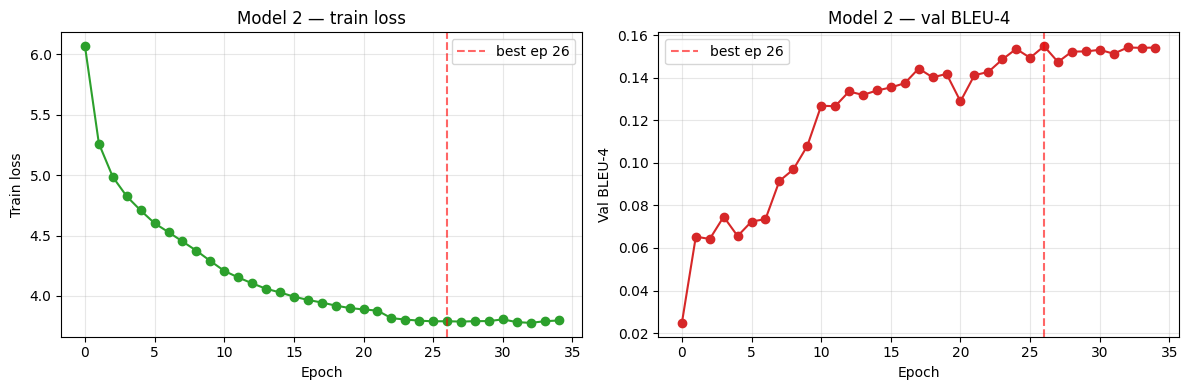

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_m2["train_loss"], marker="o", color="C2")
axes[0].axvline(best_epoch_m2, color="red", linestyle="--", alpha=0.6, label=f"best ep {best_epoch_m2}")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss"); axes[0].set_title("Model 2 — train loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

bleu4 = [b["BLEU-4"] for b in history_m2["val_bleu"]]
axes[1].plot(bleu4, marker="o", color="C3")
axes[1].axvline(best_epoch_m2, color="red", linestyle="--", alpha=0.6, label=f"best ep {best_epoch_m2}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val BLEU-4"); axes[1].set_title("Model 2 — val BLEU-4")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8.4 Test evaluation — Model 2

In [26]:
ckpt = torch.load(CHECKPOINT_DIR / "weishu_model2_best.pt", map_location=device)
model_m2.load_state_dict(ckpt["model_state"])

m2_test_greedy, m2_pred_greedy, _ = evaluate(
    model_m2, test_loader, vocab, decode="greedy", max_len=MAX_GEN_LEN,
)
m2_test_beam, m2_pred_beam, _ = evaluate(
    model_m2, test_loader, vocab, decode="beam",
    beam_size=M2_BEAM_SIZE, beam_alpha=M2_BEAM_ALPHA, max_len=MAX_GEN_LEN,
)
print("Model 2 test (greedy):", {k: round(v, 4) for k, v in m2_test_greedy.items()})
print(f"Model 2 test (beam={M2_BEAM_SIZE}, α={M2_BEAM_ALPHA}):",
      {k: round(v, 4) for k, v in m2_test_beam.items()})

Model 2 test (greedy): {'BLEU-1': 0.5887, 'BLEU-2': 0.3817, 'BLEU-3': 0.2372, 'BLEU-4': 0.1416}
Model 2 test (beam=5, α=0.7): {'BLEU-1': 0.5975, 'BLEU-2': 0.3981, 'BLEU-3': 0.2652, 'BLEU-4': 0.1756}


### 8.5 Qualitative samples — Model 2

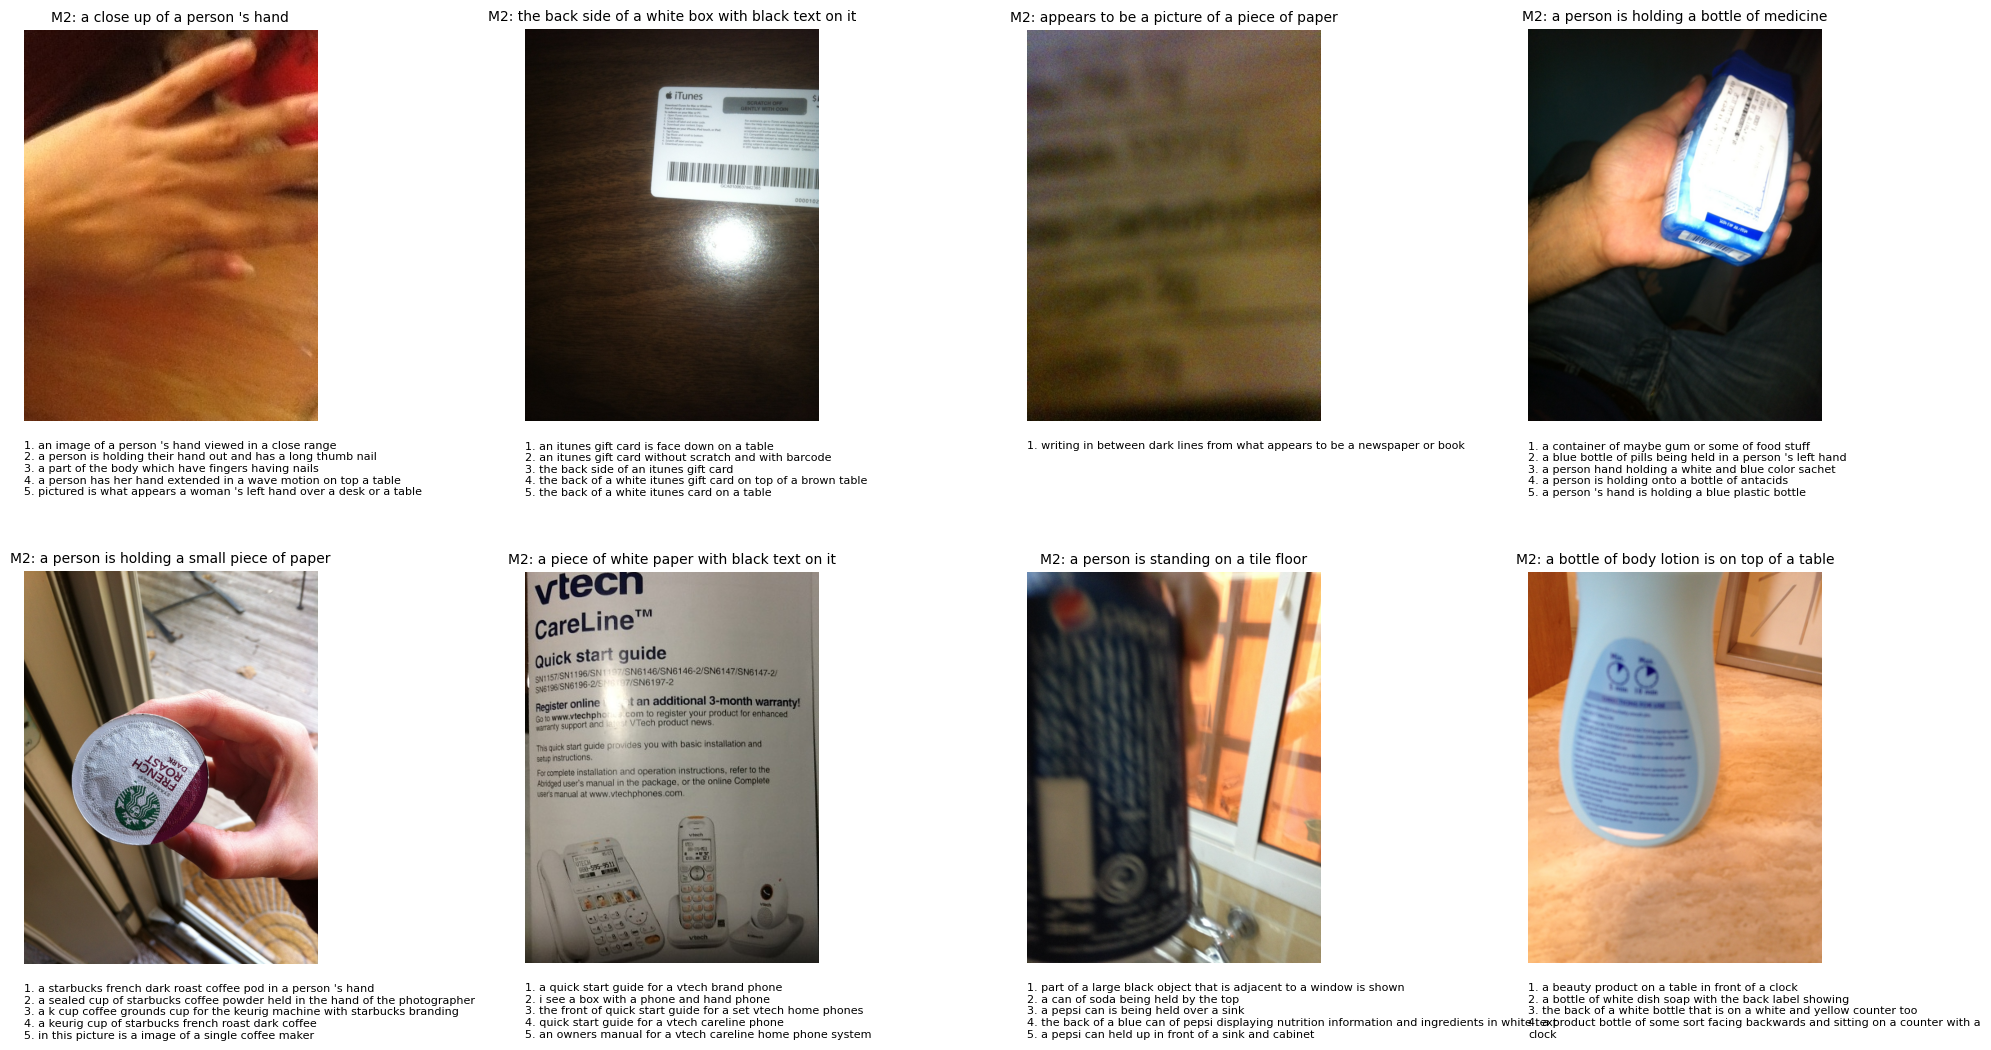

In [27]:
# Re-derive the same indices from the same seed so the two figures line up.
rng = random.Random(RANDOM_SEED)
sample_indices = rng.sample(range(len(test_data)), 8)

fig, axes = plt.subplots(2, 4, figsize=(20, 11))
for ax, idx in zip(axes.flat, sample_indices):
    item = test_data[idx]
    ax.imshow(Image.open(item["image_path"]).convert("RGB"))
    ax.axis("off")
    pred = caption_one(model_m2, item, M2_BEAM_SIZE, M2_BEAM_ALPHA)
    refs = "\n".join(f"{i+1}. {' '.join(t)}" for i, t in enumerate(item["captions_tokens"]))
    ax.set_title(f"M2: {pred}", fontsize=10)
    ax.text(0, -0.05, refs, transform=ax.transAxes, fontsize=8, va="top", wrap=True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "model2_samples.png", dpi=130, bbox_inches="tight")
plt.show()

### 8.6 Save Model 2 artefacts

In [28]:
with open(RESULTS_DIR / "model2_metrics.json", "w", encoding="utf-8") as f:
    json.dump({
        "greedy": m2_test_greedy,
        "beam": m2_test_beam,
        "beam_size": M2_BEAM_SIZE,
        "beam_alpha": M2_BEAM_ALPHA,
    }, f, indent=2)

with open(RESULTS_DIR / "model2_history.json", "w", encoding="utf-8") as f:
    json.dump({
        "train_loss": history_m2["train_loss"],
        "val_bleu": history_m2["val_bleu"],
        "ss_prob": history_m2["ss_prob"],
    }, f, indent=2)

print("saved model2_metrics.json and model2_history.json")

saved model2_metrics.json and model2_history.json


## 9. comparison

### 9.1 Training dynamics overlay

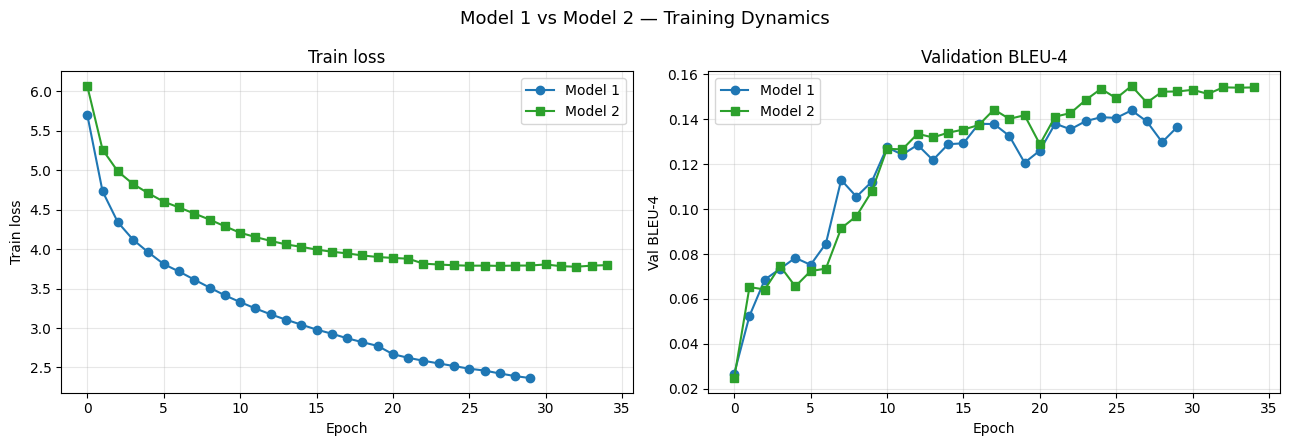

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history_m1["train_loss"], marker="o", label="Model 1", color="C0")
axes[0].plot(history_m2["train_loss"], marker="s", label="Model 2", color="C2")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train loss")
axes[0].set_title("Train loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

m1_bleu4 = [b["BLEU-4"] for b in history_m1["val_bleu"]]
m2_bleu4 = [b["BLEU-4"] for b in history_m2["val_bleu"]]
axes[1].plot(m1_bleu4, marker="o", label="Model 1", color="C0")
axes[1].plot(m2_bleu4, marker="s", label="Model 2", color="C2")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val BLEU-4")
axes[1].set_title("Validation BLEU-4"); axes[1].legend(); axes[1].grid(alpha=0.3)

fig.suptitle("Model 1 vs Model 2 — Training Dynamics", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

### 9.2 Test metrics table

In [30]:
rows = ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]
comparison = pd.DataFrame({
    "M1 (greedy)":              [m1_test_greedy[k] for k in rows],
    f"M1 (beam={M1_BEAM_SIZE}, α={M1_BEAM_ALPHA})": [m1_test_beam[k]   for k in rows],
    "M2 (greedy)":              [m2_test_greedy[k] for k in rows],
    f"M2 (beam={M2_BEAM_SIZE}, α={M2_BEAM_ALPHA})": [m2_test_beam[k]   for k in rows],
}, index=rows)
comparison["Δ BLEU-4 (beam)"] = comparison[f"M2 (beam={M2_BEAM_SIZE}, α={M2_BEAM_ALPHA})"] - \
                                comparison[f"M1 (beam={M1_BEAM_SIZE}, α={M1_BEAM_ALPHA})"]

print(comparison.round(4).to_string())
comparison.round(4).to_csv(RESULTS_DIR / "comparison_table.csv")

        M1 (greedy)  M1 (beam=3, α=0.7)  M2 (greedy)  M2 (beam=5, α=0.7)  Δ BLEU-4 (beam)
BLEU-1       0.5729              0.5881       0.5887              0.5975           0.0094
BLEU-2       0.3658              0.3858       0.3817              0.3981           0.0122
BLEU-3       0.2257              0.2504       0.2372              0.2652           0.0149
BLEU-4       0.1352              0.1586       0.1416              0.1756           0.0169


### 9.3 Side-by-side qualitative samples

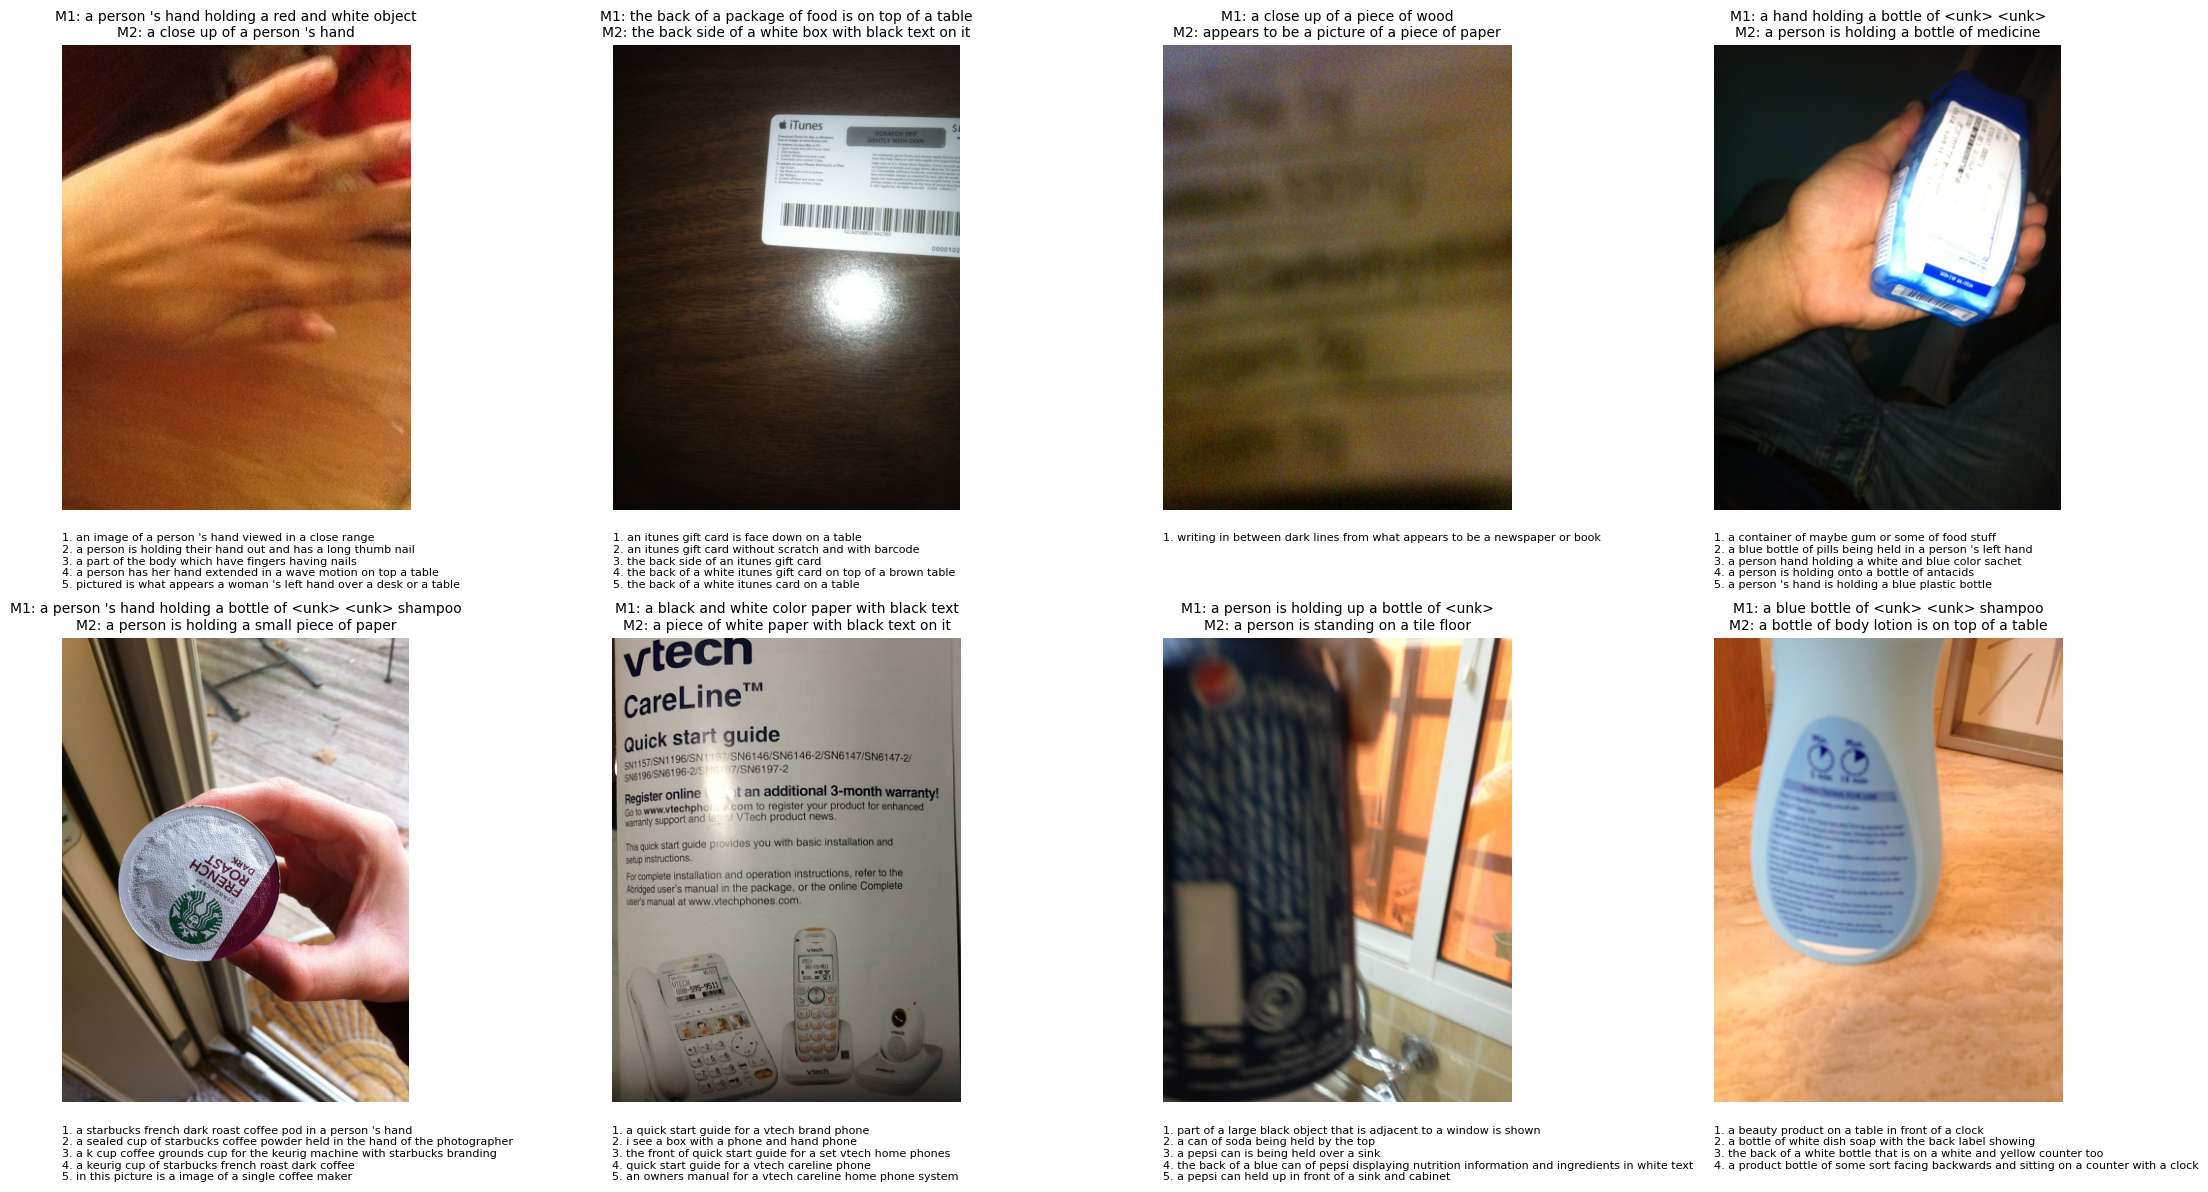

In [31]:
rng = random.Random(RANDOM_SEED)
sample_indices = rng.sample(range(len(test_data)), 8)

fig, axes = plt.subplots(2, 4, figsize=(22, 12))
for ax, idx in zip(axes.flat, sample_indices):
    item = test_data[idx]
    ax.imshow(Image.open(item["image_path"]).convert("RGB"))
    ax.axis("off")
    m1_cap = caption_one(model_m1, item, M1_BEAM_SIZE, M1_BEAM_ALPHA)
    m2_cap = caption_one(model_m2, item, M2_BEAM_SIZE, M2_BEAM_ALPHA)
    refs = "\n".join(f"{i+1}. {' '.join(t)}" for i, t in enumerate(item["captions_tokens"]))
    ax.set_title(f"M1: {m1_cap}\nM2: {m2_cap}", fontsize=10)
    ax.text(0, -0.05, refs, transform=ax.transAxes, fontsize=8, va="top", wrap=True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "model1_vs_model2_samples.png", dpi=130, bbox_inches="tight")
plt.show()